# Point 1

In [44]:
import numpy as np
import keras
from keras.models import Sequential
from keras.layers import Dense, Dropout

import matplotlib as mpl
import matplotlib.pyplot as plt
# default font
plt.rcParams['font.size'] = 13

from sklearn.preprocessing import StandardScaler

%run useful.py

# training/validation/test fractions
perc_train = 0.7
perc_valid = 0.15
perc_test = 0.15
#  check it sums to 1
assert abs(perc_train + perc_valid + perc_test - 1.0) < 1e-12

(12000, 8)
8
[1.83918812 2.04560279 5.67725029 5.95544703 9.6451452  6.53177097
 7.48906638 6.53569871] 1
[7.47714809 9.61306736 0.08388298 1.06444377 2.98703714 6.56411183
 8.09812553 8.72175914] 0
[9.64647597 7.23685347 6.42475328 7.17453621 4.67599007 3.25584678
 4.39644606 7.29689083] 0
[9.94014586 6.76873712 7.90822518 1.70914258 0.26849276 8.00370244
 9.03722538 0.2467621 ] 0
[4.91747318 5.26255167 5.9636601  0.51957545 8.95089528 7.2826618
 8.18350011 5.00222753] 1
data: 12000
train: 8400
valid: 1800
test: 1800


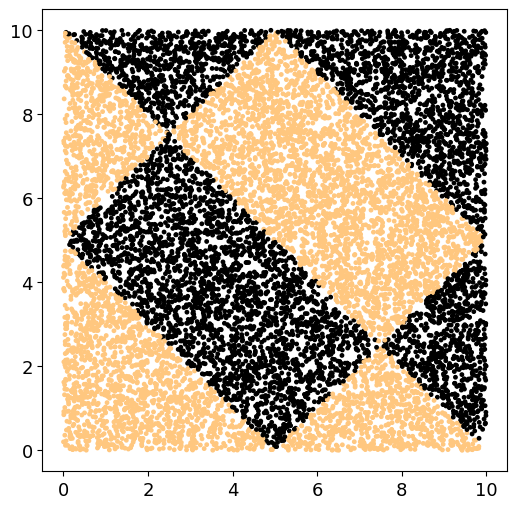

In [45]:
# Keras works with numpy arrays: just use them from the start

TYPE=3
# number of features per sample
L=8
# span of each component
B=10
x = np.loadtxt(filename("data",L,TYPE), delimiter=' ')
y = np.loadtxt(filename("labels",L,TYPE), delimiter=' ')
y = y.astype("int")
print(x.shape)
N = len(x)


# dim. of a sample
L = len(x[0])
print(L)

for i in range(5):
    print(x[i],y[i])

N_train = int(perc_train * N)
N_valid = int(perc_valid * N)
N_test = N - N_train - N_valid
print(f'data: {N}\ntrain: {N_train}\nvalid: {N_valid}\ntest: {N_test}')

plot_data(x,y)

In [46]:
def Standardize(x,m,s):
    """
    rescale each component using its mean and standard deviation
    x: data points (numpy array)
    m: mean values (numpy array)
    s: standard deviations (numpy array)
    return: rescaled data points (numpy array)
    """
    N = len(x)
    # assuming len(m)=len(s)=len(x[0])
    mm,ss = np.tile(m,(N,1)), np.tile(s,(N,1))
    return (x-mm)/ss

# split data into train/validation/test sets and check
(x_train, y_train) = (x[0:N_train],y[0:N_train])
(x_valid, y_valid) = (x[N_train:N_train+N_valid],y[N_train:N_train+N_valid])
(x_test, y_test) = (x[N_train+N_valid:],y[N_train+N_valid:])
print("Train:",len(x_train),"\t Validation:",len(x_valid),"\t Test:",len(x_test))


x_train_mean = np.mean(x_train, axis=0)
x_train_std = np.std(x_train, axis=0)
#print("train stats before rescaling:\nmean value=", x_train_mean, "\nstd. dev.=", x_train_std)

x_valid_mean = np.mean(x_valid, axis=0)
x_valid_std = np.std(x_valid, axis=0)
#print("validation stats before rescaling:\nmean value=", x_valid_mean, "\nstd. dev.=", x_valid_std)

x_test_mean = np.mean(x_test, axis=0)
x_test_std = np.std(x_test, axis=0)
#print("test stats before rescaling:\nmean value=", x_test_mean, "\nstd. dev.=", x_test_std)

x_train = Standardize(x_train, x_train_mean, x_train_std)
x_valid = Standardize(x_valid, x_valid_mean, x_valid_std)
x_test = Standardize(x_test, x_test_mean, x_test_std)
print("after rescaling (train):\nmean value=", x_train.mean(axis=0), "\nstd. dev.=", x_train.std(axis=0))

Train: 8400 	 Validation: 1800 	 Test: 1800
after rescaling (train):
mean value= [ 9.17572896e-16  1.18834043e-14 -1.95478554e-15 -3.53337069e-15
 -6.42594443e-15 -2.40365928e-15 -2.88332932e-15 -8.27623684e-15] 
std. dev.= [1. 1. 1. 1. 1. 1. 1. 1.]


In [47]:
from keras.optimizers import Adam, RMSprop, SGD

# Parametri per la Grid Search
learning_rates = [1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1]
activations = ['sigmoid', 'relu', 'elu']
dropouts = [0.0, 0.1, 0.2]
optim_names = ['adam', 'rmsprop', 'nesterov']
nepoch = 200

learning_rates_idx = 2
dropouts_idx = 1
activations_idx = 2
optim_names_idx = 0

# Helper per associare nome ottimizzatore, LR -> Oggetto Optimizer
def get_optimizer(opt_name, lr):
    if opt_name == 'adam':
        return keras.optimizers.Adam(learning_rate=lr)
    if opt_name == 'rmsprop':
        return keras.optimizers.RMSprop(learning_rate=lr)
    if opt_name == 'nesterov':
        return keras.optimizers.nesterov(learning_rate=lr)


In [48]:
# reproducibility (?)
np.random.seed(12345)
import tensorflow.random as tf_r
tf_r.set_seed(12345)

model = Sequential()
model.add(Dense(L,input_shape=(L,),activation=activations[activations_idx]))
model.add(Dense(20,activation=activations[activations_idx]))
model.add(Dropout(dropouts[dropouts_idx]))
model.add(Dense(20,activation=activations[activations_idx]))
model.add(Dropout(dropouts[dropouts_idx]))
model.add(Dense(20,activation=activations[activations_idx]))
model.add(Dropout(dropouts[dropouts_idx]))
model.add(Dense(1,activation='sigmoid'))

print(model.summary())

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_20 (Dense)                │ (None, 8)              │            72 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 20)             │           180 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 20)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 20)             │           420 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 20)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 20)             │           420 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 20)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 1)              │            21 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,113 (4.35 KB)

 Trainable params: 1,113 (4.35 KB)

 Non-trainable params: 0 (0.00 B)

None


In [49]:
model.compile(
    optimizer=get_optimizer(optim_names[optim_names_idx], lr=learning_rates[learning_rates_idx]),
    loss=keras.losses.BinaryCrossentropy(),
    metrics=['accuracy'],
)

In [50]:
fit = model.fit(x_train, y_train,
               epochs = nepoch, batch_size = 50,
               validation_data=(x_valid,y_valid),
               verbose=2)

Epoch 1/200
168/168 - 2s - 14ms/step - accuracy: 0.5177 - loss: 0.7070 - val_accuracy: 0.5144 - val_loss: 0.6897
Epoch 2/200
168/168 - 0s - 2ms/step - accuracy: 0.5245 - loss: 0.7017 - val_accuracy: 0.5200 - val_loss: 0.6863
Epoch 3/200
168/168 - 0s - 3ms/step - accuracy: 0.5282 - loss: 0.6965 - val_accuracy: 0.5300 - val_loss: 0.6842
Epoch 4/200
168/168 - 0s - 2ms/step - accuracy: 0.5323 - loss: 0.6917 - val_accuracy: 0.5367 - val_loss: 0.6829
Epoch 5/200
168/168 - 0s - 2ms/step - accuracy: 0.5348 - loss: 0.6911 - val_accuracy: 0.5400 - val_loss: 0.6820
Epoch 6/200
168/168 - 0s - 2ms/step - accuracy: 0.5371 - loss: 0.6888 - val_accuracy: 0.5378 - val_loss: 0.6813
Epoch 7/200
168/168 - 0s - 2ms/step - accuracy: 0.5325 - loss: 0.6917 - val_accuracy: 0.5372 - val_loss: 0.6805
Epoch 8/200
168/168 - 0s - 2ms/step - accuracy: 0.5349 - loss: 0.6880 - val_accuracy: 0.5350 - val_loss: 0.6799
Epoch 9/200
168/168 - 0s - 2ms/step - accuracy: 0.5331 - loss: 0.6877 - val_accuracy: 0.5344 - val_loss

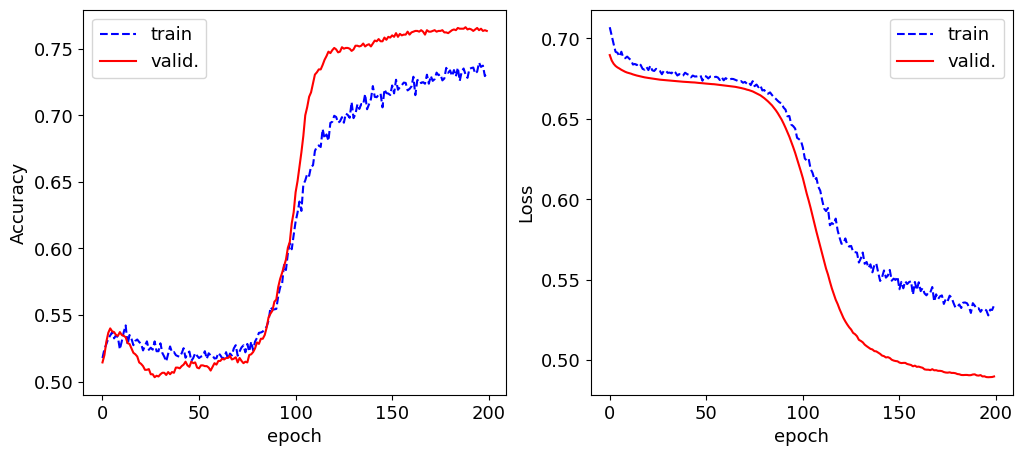

In [51]:
fig,AX=plt.subplots(1,2,figsize=(12,5.))
ax=AX[0]
ax.plot(fit.history['accuracy'],label="train",c="b",ls="--")
ax.plot(fit.history['val_accuracy'],label="valid.",c="r")
ax.set_xlabel('epoch')
ax.set_ylabel("Accuracy")
ax.legend()
ax=AX[1]
ax.plot(fit.history['loss'],label="train",c="b",ls="--")
ax.plot(fit.history['val_loss'],label="valid.",c="r")
ax.set_xlabel('epoch')
ax.set_ylabel("Loss")
ax.legend()

In [52]:
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f"Final test loss: {test_loss:.4f}")
print(f"Final test accuracy: {test_acc:.4f}")

Final test loss: 0.4946
Final test accuracy: 0.7550


319/319 ━━━━━━━━━━━━━━━━━━━━ 0s 877us/step


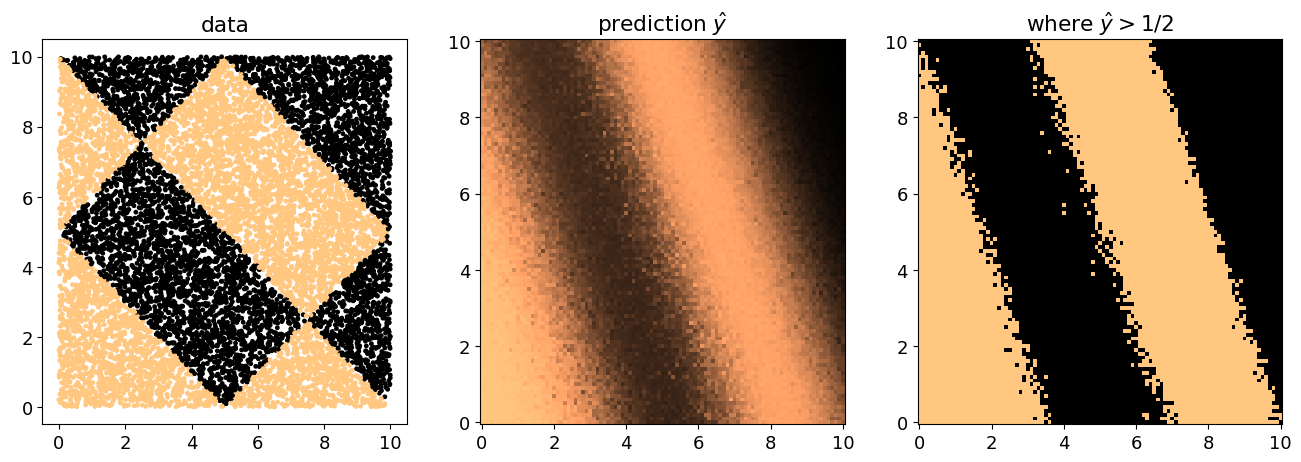

remember: these are 2 out of L=8 dimensions, of which L-2 contain random noise


In [53]:
dX = .1
X1 = np.arange(0,10+dX, dX)
LG = len(X1)
# 2D meshgrid
X, Y = np.meshgrid(X1, X1)
allXY = np.reshape((np.array((X,Y)).T),(LG**2,2))
#create synthetic inputs with L features for each grid point; initialized randomly in [0, B].
grid = np.random.rand(LG**2,L)*B
#replace first 2 features with the actual 2D coordinates
grid[:,:2] = allXY
#standardize using train-set mean/std before prediction
grid_r=Standardize(grid,x_train_mean,x_train_std)

pred = model.predict(grid_r)

fig,AX=plt.subplots(1,3,figsize=(16,5.))
ax=AX[0]
ax.scatter(x[:,0],x[:,1],c=y,s=6)
ax.set_title("data")
ax=AX[1]
ax.pcolormesh(X1,X1,pred.reshape((LG, LG)))
ax.set_title("prediction $\\hat y$")
ax=AX[2]
pred01=np.copy(pred)
pred01[pred>0.5]=1
pred01[pred<=0.5]=0
ax.pcolormesh(X1,X1,pred01.reshape((LG, LG)))
ax.set_title("where $\\hat y > 1/2$")
plt.show()
print(f"remember: these are 2 out of L={L} dimensions, of which L-2 contain random noise")